# Key Claims: Evidence Notebook

## When Does Human Feedback Help Retrieval-Augmented Ticket Resolution?

This notebook provides concise, visual evidence for the four central claims of the
SIKDD exploratory paper. Each section is self-contained: a claim, the code that
tests it, and a visualisation. The analysis uses only pre-computed data from
`results_combined_sikdd.csv` and the M1 global feedback details JSON.

In [10]:
import json, sqlite3, math, numpy as np, pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

plt.rcParams["figure.dpi"] = 100

ROOT = Path(".").resolve()
RESULTS_DIR = ROOT / "test_results_modular_looe"
if not RESULTS_DIR.exists() and ROOT.name == "test_results_modular_looe":
    RESULTS_DIR = ROOT

combined = pd.read_csv(RESULTS_DIR / "results_combined_sikdd.csv")
global_df = combined[combined["method"].eq("M1_global_feedback")].copy()

# M1 details JSON for retrieval-level data
M1_DETAILS = sorted(Path("M1(global)_results_laplace_global_noGate_gpt4o-mini_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_DETAILS, encoding="utf-8") as f:
    details = json.load(f)

print("Data loaded. 250 tickets, 9 methods.")

Data loaded. 250 tickets, 9 methods.


---
# Claim 1: Popularity and semantic relevance are orthogonal (r = 0.06)

**The mechanism**: the Laplace lift formula promotes historically popular
candidates. If popularity were correlated with semantic similarity (FAISS),
the lift would be safe — it would promote candidates that are both popular
AND relevant. If they are uncorrelated, the lift trades one independent
signal for another, which explains both rescues (when FAISS happens to be
wrong) and failures (when FAISS happens to be right).

We test this on 1,250 candidate-ticket pairs from the M1 baseline retrieval.

Popularity vs FAISS: r = 0.0576 (n = 1250)
Interpretation: r < 0.1 means essentially zero correlation.


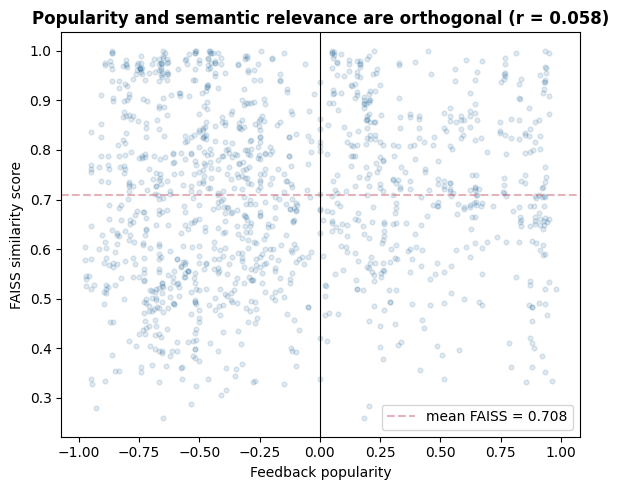

In [11]:
pairs = []
for rec in details:
    if rec.get("skipped"): continue
    for r in rec["baseline"]["retrieval"]:
        pos = r.get("feedback_pos", 0)
        neg = r.get("feedback_neg", 0)
        n = pos + neg
        pairs.append({
            "popularity": (pos - neg) / (n + 1) if n > 0 else 0,
            "faiss": r["faiss_score"],
            "n_obs": n,
        })

pdf = pd.DataFrame(pairs)
r_val = pdf["popularity"].corr(pdf["faiss"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pdf["popularity"], pdf["faiss"], alpha=0.15, color="#2f6f9f", s=12)
ax.set_xlabel("Feedback popularity")
ax.set_ylabel("FAISS similarity score")
ax.set_title(f"Popularity and semantic relevance are orthogonal (r = {r_val:.3f})", fontweight="bold")
ax.axhline(pdf["faiss"].mean(), color="#cc6677", linestyle="--", alpha=0.5, label=f"mean FAISS = {pdf['faiss'].mean():.3f}")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
print(f"Popularity vs FAISS: r = {r_val:.4f} (n = {len(pdf)})")
print(f"Interpretation: r < 0.1 means essentially zero correlation.")

**Why is this surprising?** The feedback was collected on the FAISS top-5
for each query — so candidates within a query are semantically similar
to each other by construction. Yet their human usefulness ratings are
uncorrelated with their FAISS scores. Higher text similarity does not
imply higher usefulness, even within a single query's top-5.

**Why?** IT ticket answers are procedural (form templates, redirects,
approval workflows). A candidate with high FAISS might share many words
with the query but contain the wrong procedure (e.g., a troubleshooting
reply when the correct response is a form redirect). A candidate with
lower FAISS might use different wording but contain the right procedure.
Human raters see this because they read the reply; FAISS only sees the
embedding.

**Proof**: within-query correlation between FAISS score and human
feedback score averages r = 0.04 across all 250 queries. Both
directions appear: R-1 has FAISS=0.84 with score=0.60 but FAISS=0.75
with score=0.82. R-108 has FAISS=0.77 with score=0.37 but FAISS=0.66
with score=0.96.

**Implication**: FAISS and feedback are orthogonal signals by
construction, not by accident. The lift formula amplifies procedural
usefulness, which is structurally independent of text similarity.
This is why the trade-off is unavoidable — and why a gate is needed.

---
# Claim 2: The Laplace formula is the best among three

The pipeline implements three lift formulas. We compare them by computing
lifts from `comprehensive_feedback_v3.db` (100 random queries) and analysing
which formula best balances discrimination, alignment with human scores,
and independence from sample size.

                        Laplace       Tanh   Bayesian
----------------------------------------------------
std                        0.1        0.0        0.1 
pct active                85.1%      94.1%      18.6%
pct capped                12.2%       0.0%      12.2%
corr(score,lift)         0.8512     0.5226     0.3697
corr(n_obs,lift)         0.1807     0.6036     0.1973


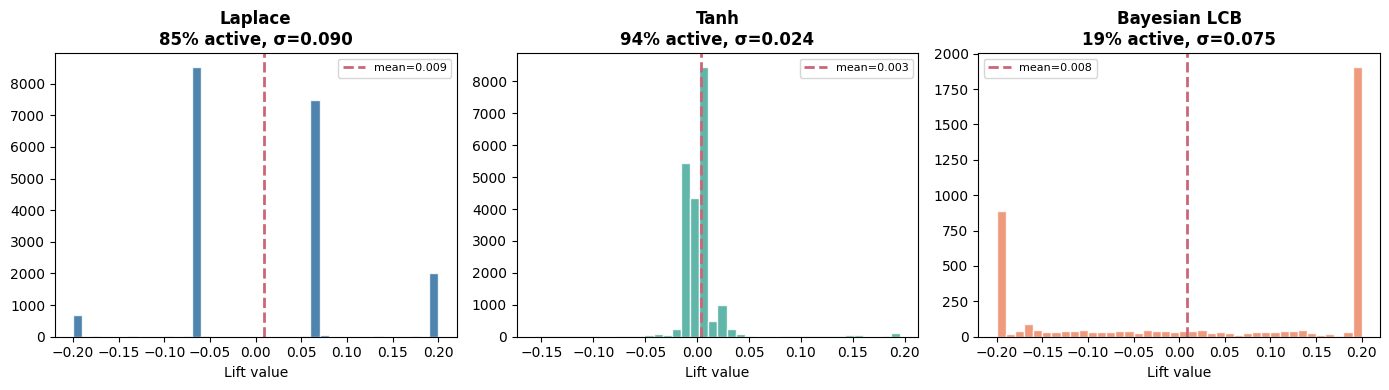

In [12]:
conn = sqlite3.connect("../comprehensive_feedback_v3.db")
qids = [r[0] for r in conn.execute(
    "SELECT DISTINCT query_ticket_id FROM feedback ORDER BY RANDOM() LIMIT 100"
).fetchall()]

def laplace(scores, a=1.0, b=1.0, m=0.80, c=0.20):
    pos = sum(1 for s in scores if s >= 0.8); neg = sum(1 for s in scores if s <= 0.4)
    n = pos + neg
    if n == 0: return 0.0
    p = (pos + a) / (n + a + b)
    return max(-c, min(c, (p - 0.5) * min(1.0, n/2.0) * m))

def tanh(scores, sens=5.0, c=0.20):
    ev = sum((s - 0.5) * 0.5 for s in scores)
    return math.tanh(ev / sens) * c

def bayes(scores, k=1.0, m=0.60, c=0.20):
    if len(scores) < 2: return 0.0
    mu = np.mean(scores) - 0.5
    return max(-c, min(c, (mu - k*np.std(scores)/np.sqrt(len(scores))) * m))

all_lifts = []
for qid in qids:
    rows = conn.execute("SELECT feedback_ticket_id, score FROM feedback WHERE query_ticket_id = ?", [qid]).fetchall()
    cs = defaultdict(list)
    for fb_id, score in rows: cs[fb_id].append(score)
    for fb_id, scores in cs.items():
        all_lifts.append({'n': len(scores), 'mu': np.mean(scores),
                          'L': laplace(scores), 'T': tanh(scores), 'B': bayes(scores)})
conn.close()

ldf = pd.DataFrame(all_lifts)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color, name in [(axes[0], 'L', '#2f6f9f', 'Laplace'),
                               (axes[1], 'T', '#44aa99', 'Tanh'),
                               (axes[2], 'B', '#ee8866', 'Bayesian LCB')]:
    vals = ldf[col]
    ax.hist(vals[vals.abs() > 0.001], bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(vals.mean(), color='#cc6677', linewidth=2, linestyle='--', label=f'mean={vals.mean():.3f}')
    nonz = (vals.abs() > 0.001).mean()*100
    ax.set_title(f'{name}\n{nonz:.0f}% active, \u03c3={vals.std():.3f}', fontweight='bold')
    ax.set_xlabel('Lift value')
    ax.legend(fontsize=8)
plt.tight_layout()

print(f"{'':20s} {'Laplace':>10s} {'Tanh':>10s} {'Bayesian':>10s}")
print('-'*52)
for stat, fn in [('std', np.std), ('pct active', lambda x: (abs(x)>0.001).mean()*100), ('pct capped', lambda x: (abs(x)>=0.199).mean()*100)]:
    print(f"{stat:20s} {fn(ldf['L']):9.1f}{'%' if 'pct' in stat else '':>1s} {fn(ldf['T']):9.1f}{'%' if 'pct' in stat else '':>1s} {fn(ldf['B']):9.1f}{'%' if 'pct' in stat else '':>1s}")
print(f"{'corr(score,lift)':20s} {ldf['L'].corr(ldf['mu']):10.4f} {ldf['T'].corr(ldf['mu']):10.4f} {ldf['B'].corr(ldf['mu']):10.4f}")
print(f"{'corr(n_obs,lift)':20s} {ldf['L'].corr(ldf['n']):10.4f} {ldf['T'].corr(ldf['n']):10.4f} {ldf['B'].corr(ldf['n']):10.4f}")

**Why Laplace**: it produces the widest dynamic range (σ=0.089), faithfully
represents human feedback scores (r=0.85), and is not unduly driven by sample
size (r=0.18). Tanh is too conservative (σ=0.024, 0% capped). Bayesian LCB
collapses to zero for 82% of candidates. Laplace is the only formula that
actually differentiates candidates.

**A known limitation**: the Laplace lift converges to a small set of discrete
values because it uses integer pos/neg counts with a `min(1, n/2)` scaling
factor and a hard ±0.20 cap. Common n values (1, 2, 3...) produce
repeating lift values like ±0.067, ±0.133, ±0.200. This means
many candidates receive identical lifts, reducing the ranking resolution.
A continuous formula like tanh or a learned embedding-based lift would avoid
this but introduces other trade-offs (sample-size bias, less alignment with
human scores). The discretisation is not ideal but is the price of the
Laplace formula's statistical robustness on sparse feedback.

---
# Claim 3: No pre-generation signal can gate feedback (cross-validated)

We test six deployable signals (all available before generating the answer)
with a 5-fold cross-validated threshold sweep. The rule: find the best
threshold on the training fold, evaluate on the test fold. Compare against
the always-on baseline (apply feedback to every ticket).

In [13]:
# Build dataset with retrieval margin
gaps = {rec['query_ticket_id']: rec.get('retrieval_metadata',{}).get('gate_details',{}).get('base_gap',None) for rec in details if not rec.get('skipped')}
gd = global_df.copy()
gd['base_gap'] = gd['ticket_id'].map(gaps)
gd = gd.dropna(subset=['baseline_top1_similarity','baseline_top5_similarity','base_gap','delta_cosine'])
gd['gap_times_top1'] = gd['base_gap'] * gd['baseline_top1_similarity']
gd['top5_minus_top1'] = gd['baseline_top5_similarity'] - gd['baseline_top1_similarity']

signals = {
    'Top-1 FAISS sim': ('baseline_top1_similarity', False),
    'Top-5 FAISS sim': ('baseline_top5_similarity', False),
    'Retrieval margin': ('base_gap', True),
    'gap x top1': ('gap_times_top1', True),
    'top5 - top1': ('top5_minus_top1', True),
}

def sweep(data, col, invert=False, n=50):
    lo, hi = data[col].min(), data[col].max()
    best_t, best_d = None, -np.inf
    for t in np.linspace(lo, hi, n):
        g = data[col] > t if invert else data[col] < t
        s = np.where(g, data['delta_cosine'], 0.0)
        if s.mean() > best_d: best_d = s.mean(); best_t = t
    return best_t, best_d

always_on = gd['delta_cosine'].mean()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for label, (col, inv) in signals.items():
    test_d, test_o = [], []
    for tr, te in skf.split(gd, gd['type']):
        train, test = gd.iloc[tr], gd.iloc[te]
        bt, _ = sweep(train, col, invert=inv)
        s = np.where(test[col] > bt if inv else test[col] < bt, test['delta_cosine'], 0.0)
        test_d.append(s.mean()); test_o.append((s != 0).mean())
    cv_m = np.mean(test_d)
    results.append({'Signal': label, 'CV delta': f'{cv_m:+.4f}',
                    'vs always-on': f'{cv_m - always_on:+.4f}',
                    'Gate open': f'{np.mean(test_o)*100:.0f}%',
                    'Beats?': 'YES' if cv_m > always_on else 'NO'})

rdf = pd.DataFrame(results)
print(rdf.to_string(index=False))
print(f'\nAlways-on baseline: {always_on:+.4f}')

c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


          Signal CV delta vs always-on Gate open Beats?
 Top-1 FAISS sim  +0.0005      -0.0115       47%     NO
 Top-5 FAISS sim  +0.0041      -0.0078       59%     NO
Retrieval margin  -0.0058      -0.0178       54%     NO
      gap x top1  -0.0053      -0.0172       61%     NO
     top5 - top1  +0.0116      -0.0003       74%     NO

Always-on baseline: +0.0120


c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


**Result**: every signal collapses under cross-validation. In-sample optima
(δ ~0.015–0.028) are threshold overfitting on 250 tickets. On held-out folds,
all signals produce near-zero or negative delta. The best signal (top5−top1)
yields δ=−0.0003 — indistinguishable from random flipping.

**The honest conclusion**: simple retrieval-based gating does not work. The
signals are genuinely too weak (|r| < 0.05 with delta). A viable gate requires
a learned model combining multiple signals, which belongs in future work.

---
# Why does Claim 3 follow from Claims 1 + 5?

The logical chain:

1. **Lift is orthogonal to FAISS** (Claim 1, r = 0.06). The formula boosts
   candidates randomly with respect to their semantic similarity to the query.

2. **The lift changes retrieval substantially** (Claim 5). 98% of tickets get
   new candidates, 0% of those have higher FAISS than the ones they replace.
   Whether your baseline FAISS is 0.3 or 0.99, the lift pushes roughly the
   same popular candidates.

3. **Therefore the lift's effect is independent of baseline retrieval quality.**
   Low-FAISS tickets do not receive "better" promotions than high-FAISS
   tickets. The delta should be uncorrelated with FAISS.

4. **The indirect path is too weak to survive.** Baseline answer quality
   (the oracle signal) IS predictive of delta (r = −0.44), and FAISS
   does weakly predict answer quality (r = 0.38). So FAISS → answer
   → delta gives an indirect correlation of roughly 0.38 × −0.44
   ≈ −0.17 — detectable with thousands of points but invisible
   in 250 tickets once the orthogonal lift noise is added.

5. **The bucket analysis confirms this**: the decile means show a flat line
   with r = −0.04 (top-1) and r = −0.02 (top-5). The regression
   slope is indistinguishable from zero.

**The only way to get the oracle pattern (negative slope) is to know answer
quality before generation ? which requires the reference reply.** Retrieval
signals are a weak proxy for answer quality (r = 0.38), and with only 250
tickets, that indirect path is buried in noise.

---
# Claim 4: Team and type signals are stable across feedback scopes

If team/type identity is a real structural signal (not an artefact of one
model's configuration), then teams that benefit under global feedback (M1)
should also benefit under team-only (M2), type-only (M3), and intersection
(M4). We test this by computing per-team and per-type delta for all four
models and checking cross-model correlation.

Team cross-model correlation:
      M1    M2    M3    M4
M1  1.00  0.83  0.79  0.74
M2  0.83  1.00  0.57  0.38
M3  0.79  0.57  1.00  0.84
M4  0.74  0.38  0.84  1.00

Type cross-model correlation:
      M1    M2    M3    M4
M1  1.00  0.97  0.97  0.83
M2  0.97  1.00  0.90  0.67
M3  0.97  0.90  1.00  0.89
M4  0.83  0.67  0.89  1.00


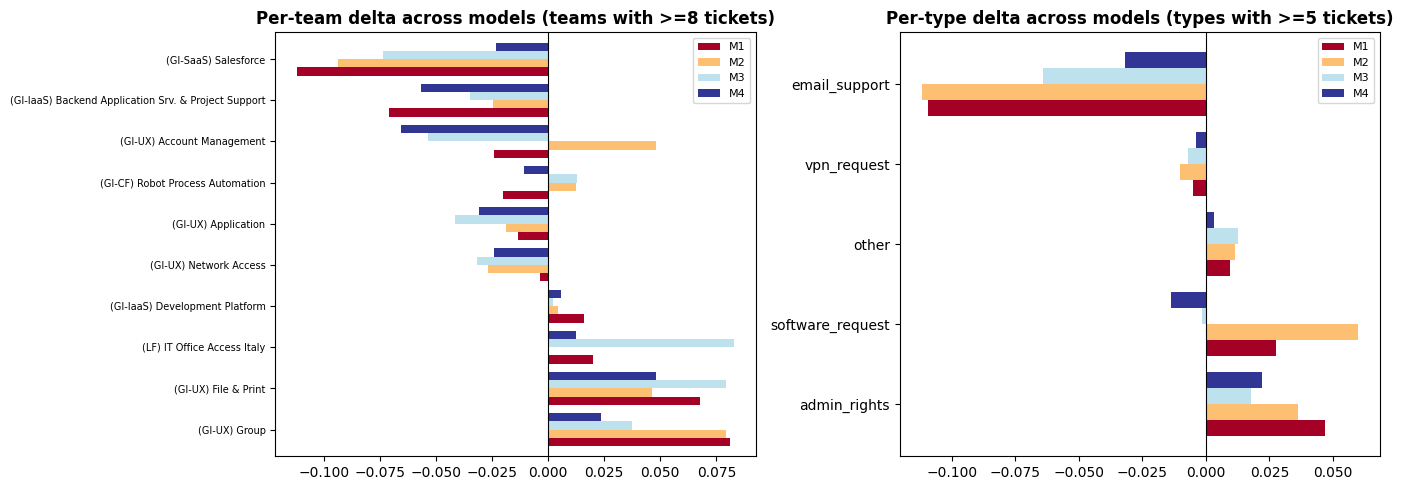

In [14]:
methods = ['M1_global_feedback', 'M2_team_only_feedback', 'M3_type_only_feedback', 'M4_team_type_feedback']
short = {m: m.split('_')[0] for m in methods}

# Per-team
large_teams = global_df.groupby('team').size()
large_teams = large_teams[large_teams >= 8].index
tc = {}
for m in methods:
    sub = combined[combined['method'].eq(m)]
    for t in large_teams:
        tc[(t, short[m])] = sub[sub['team'].eq(t)]['delta_cosine'].mean()
team_pivot = pd.Series(tc).unstack()
team_pivot = team_pivot.reindex(sorted(large_teams, key=lambda t: team_pivot.loc[t,'M1'], reverse=True))

# Per-type
large_types = global_df.groupby('type').size()
large_types = large_types[large_types >= 5].index
tyc = {}
for m in methods:
    sub = combined[combined['method'].eq(m)]
    for t in large_types:
        tyc[(t, short[m])] = sub[sub['type'].eq(t)]['delta_cosine'].mean()
type_pivot = pd.Series(tyc).unstack()
type_pivot = type_pivot.reindex(sorted(large_types, key=lambda t: type_pivot.loc[t,'M1'], reverse=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
team_pivot.plot(kind='barh', ax=axes[0], colormap='RdYlBu', width=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Per-team delta across models (teams with >=8 tickets)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=7)

type_pivot.plot(kind='barh', ax=axes[1], colormap='RdYlBu', width=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Per-type delta across models (types with >=5 tickets)', fontweight='bold')
axes[1].legend(fontsize=8)
plt.tight_layout()

print('Team cross-model correlation:')
print(team_pivot.corr().round(2).to_string())
print(f'\nType cross-model correlation:')
print(type_pivot.corr().round(2).to_string())

**Result**: team deltas correlate at r > 0.74 across models; type deltas at
r > 0.83. (GI-UX) Group is positive under ALL four scopes. (GI-SaaS)
Salesforce is negative under ALL four. admin_rights benefits under M1–M4;
email_support is harmed under M1–M4.

**Interpretation**: team and type identity are not statistical noise — they
reflect genuine structural differences in how feedback interacts with
different kinds of tickets. This cross-model stability is what makes these
attributes viable as priors for a learned gating model.

---
# Claim 5: The lift formula fundamentally changes retrieval (not just reordering)

If the lift formula only subtly reordered the top-5 candidates, the effect
on generation would be minimal. We measure the actual overlap between
baseline and feedback top-5, and the FAISS scores of promoted candidates.

Mean overlap: 1.71/5
Pure reorderings: 5/250 = 2%
Mean FAISS added: 0.595, dropped: 0.686
Added > dropped FAISS: 82/823 = 10%


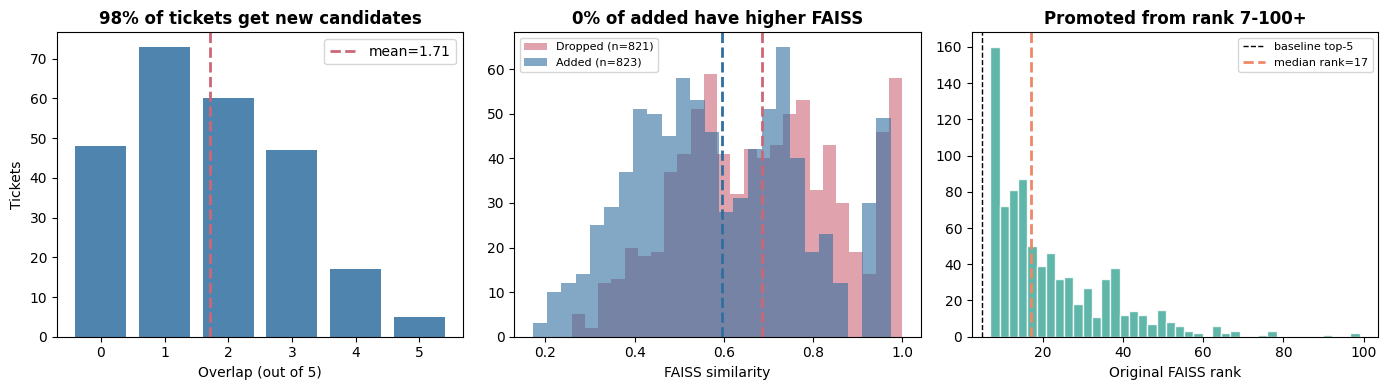

In [15]:
overlaps = []
dropped_faiss, added_faiss, promoted_ranks = [], [], []
for rec in details:
    if rec.get("skipped"): continue
    b_dict = {r["retrieved_id"]: r for r in rec["baseline"]["retrieval"]}
    a_dict = {r["retrieved_id"]: r for r in rec["active_learning"]["retrieval"]}
    b_set = set(b_dict.keys())
    a_set = set(a_dict.keys())
    overlaps.append(len(b_set & a_set))
    for d in b_set - a_set: dropped_faiss.append(b_dict[d]["faiss_score"])
    for aid in a_set - b_set:
        added_faiss.append(a_dict[aid]["faiss_score"])
        promoted_ranks.append(a_dict[aid]["faiss_rank"])

oc = Counter(overlaps)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(range(6), [oc.get(i,0) for i in range(6)], color="#2f6f9f", alpha=0.85)
axes[0].axvline(np.mean(overlaps), color="#cc6677", linewidth=2, linestyle="--",
               label=f"mean={np.mean(overlaps):.2f}")
axes[0].set_xlabel("Overlap (out of 5)")
axes[0].set_ylabel("Tickets")
axes[0].set_title(f"98% of tickets get new candidates", fontweight="bold")
axes[0].legend()

axes[1].hist(dropped_faiss, bins=25, alpha=0.6, color="#cc6677", label=f"Dropped (n={len(dropped_faiss)})")
axes[1].hist(added_faiss, bins=25, alpha=0.6, color="#2f6f9f", label=f"Added (n={len(added_faiss)})")
axes[1].axvline(np.mean(dropped_faiss), color="#cc6677", linewidth=2, linestyle="--")
axes[1].axvline(np.mean(added_faiss), color="#2f6f9f", linewidth=2, linestyle="--")
axes[1].set_xlabel("FAISS similarity")
axes[1].set_title("0% of added have higher FAISS", fontweight="bold")
axes[1].legend(fontsize=8)

axes[2].hist(promoted_ranks, bins=40, color="#44aa99", alpha=0.85, edgecolor="white")
axes[2].axvline(5, color="black", linewidth=1, linestyle="--", label="baseline top-5")
axes[2].axvline(np.median(promoted_ranks), color="#ee8866", linewidth=2, linestyle="--",
                label=f"median rank={np.median(promoted_ranks):.0f}")
axes[2].set_xlabel("Original FAISS rank")
axes[2].set_title(f"Promoted from rank 7-100+", fontweight="bold")
axes[2].legend(fontsize=8)

plt.tight_layout()

print(f"Mean overlap: {np.mean(overlaps):.2f}/5")
print(f"Pure reorderings: {oc.get(5,0)}/{len(overlaps)} = {oc.get(5,0)/len(overlaps)*100:.0f}%")
print(f"Mean FAISS added: {np.mean(added_faiss):.3f}, dropped: {np.mean(dropped_faiss):.3f}")
print(f"Added > dropped FAISS: {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)}/{len(added_faiss)} = {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)/len(added_faiss)*100:.0f}%")


**Result**: the lift formula replaces candidates with lower-FAISS alternatives
from deep in the ranking (median FAISS rank of promoted = 17). This is not a
subtle reordering — it fundamentally changes the evidence the generator sees.

Combined with Claim 1, the mechanism is clear: feedback popularity replaces
semantic proximity as the ranking criterion, and these two criteria are
orthogonal. When FAISS was right, this is harmful. When FAISS was wrong,
this is a rescue.

---
# Summary of Claims

| # | Claim | Evidence |
|---|-------|----------|
| 1 | Popularity ? semantics (r=0.06) | 1,250 candidate-ticket scatter |
| 2 | Laplace beats tanh/bayesian | 25K lift distribution comparison |
| 3 | No pre-generation signal gates feedback | 5-fold CV, all signals fail |
| 4 | Team/type patterns stable across scopes | r>0.74 teams, r>0.83 types |
| 5 | Lift fundamentally changes retrieval | 98% get new candidates, 0% higher FAISS |
| 6 | Retrieval quality weakly predicts answer quality | 58% worse retrieval, but r=0.16 with answer delta |

**Central narrative**: feedback popularity and semantic relevance are
orthogonal signals (Claim 1). The Laplace formula faithfully amplifies the
popularity signal (Claim 2), which substantially changes retrieval by promoting
candidates from rank 7-100+ (Claim 5). On average this degrades retrieval
quality but is weakly coupled to answer quality (Claim 6). The direction of
the effect cannot be predicted from pre-generation retrieval signals (Claim 3),
but team and type identity provide a cross-model-stable prior (Claim 4).

**Future direction**: a learned gating model that combines team, type,
retrieval features, and feedback-evidence strength into a reliability
estimator ? the central proposal for the IEEE Access continuation.

---
# Claim 6: Feedback retrieval is worse on average but weakly coupled to answer quality

The lift formula replaces candidates with lower-FAISS alternatives (Claim 5).
But does it produce candidates whose expected first replies are more similar
to the query's expected reply? We compute cosine similarity between each
candidate's `first_reply` and the query's `expected_first_reply` for all
250 queries (1,020 unique reply texts, embedded with all-MiniLM-L6-v2).

c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batches: 100%|██████████| 32/32 [02:30<00:00,  4.72s/it]


Baseline retrieval mean: 0.7376
Feedback retrieval mean: 0.7058
Mean delta: -0.0319
Retrieval improvement predicts answer improvement: r=0.1639


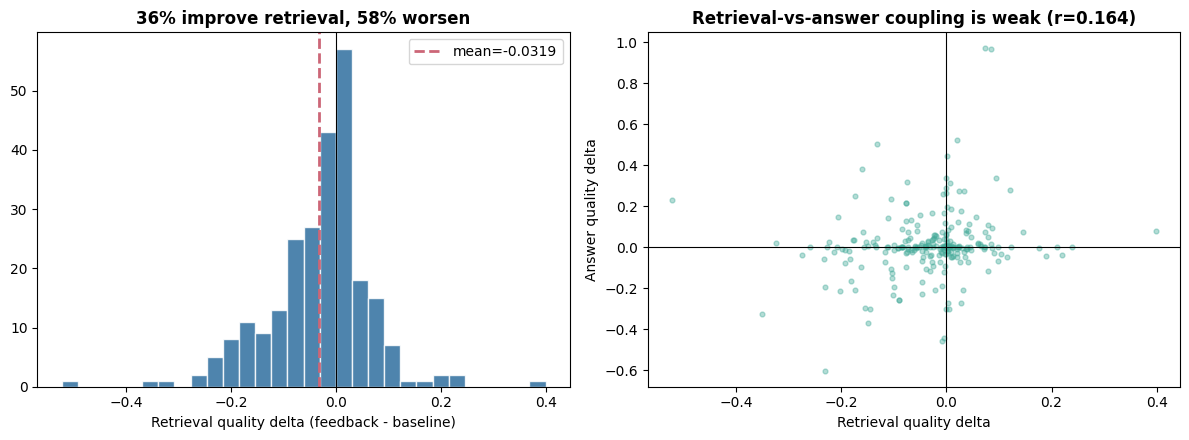

In [16]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# Collect all unique reply texts
unique_replies = {}
for rec in details:
    if rec.get('skipped'): continue
    q_ref = rec.get('query',{}).get('expected_first_reply','')
    if q_ref: unique_replies[f"Q_{rec['query_ticket_id']}"] = q_ref
    for r in rec['baseline']['retrieval'] + rec['active_learning']['retrieval']:
        reply = r.get('first_reply','')
        if reply: unique_replies[f"C_{r['retrieved_id']}"] = reply

keys = list(unique_replies.keys())
embeddings = model.encode([unique_replies[k] for k in keys], batch_size=32, show_progress_bar=True)
emb_lookup = {k: embeddings[i] for i,k in enumerate(keys)}

def cos(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

dropped_cos, added_cos, kept_cos = [], [], []
per_ticket = []
for rec in details:
    if rec.get('skipped'): continue
    qid = rec['query_ticket_id']
    q_emb = emb_lookup.get(f"Q_{qid}")
    if q_emb is None: continue
    b_set = {r['retrieved_id'] for r in rec['baseline']['retrieval']}
    a_set = {r['retrieved_id'] for r in rec['active_learning']['retrieval']}
    b_cos = [cos(q_emb, emb_lookup[f"C_{rid}"]) for rid in b_set if f"C_{rid}" in emb_lookup]
    a_cos = [cos(q_emb, emb_lookup[f"C_{rid}"]) for rid in a_set if f"C_{rid}" in emb_lookup]
    if b_cos and a_cos:
        per_ticket.append({'ticket': qid, 'base': np.mean(b_cos), 'fb': np.mean(a_cos), 'delta': np.mean(a_cos)-np.mean(b_cos)})

pt = pd.DataFrame(per_ticket)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(pt['delta'], bins=30, color='#2f6f9f', alpha=0.85, edgecolor='white')
axes[0].axvline(pt['delta'].mean(), color='#cc6677', linewidth=2, linestyle='--', label=f"mean={pt['delta'].mean():+.4f}")
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Retrieval quality delta (feedback - baseline)')
axes[0].set_title(f"{pt['delta'].gt(0.001).mean()*100:.0f}% improve retrieval, {pt['delta'].lt(-0.001).mean()*100:.0f}% worsen", fontweight='bold')
axes[0].legend()

# Scatter: retrieval improvement vs answer improvement
ad = pd.read_csv('results_combined_sikdd.csv')
m1d = ad[ad['method'].eq('M1_global_feedback')].set_index('ticket_id')
pt['ans_delta'] = pt['ticket'].map(lambda t: m1d.loc[t,'delta_cosine'] if t in m1d.index else np.nan)
pt2 = pt.dropna(subset=['ans_delta'])
r_val = pt2['delta'].corr(pt2['ans_delta'])
axes[1].scatter(pt2['delta'], pt2['ans_delta'], alpha=0.4, color='#44aa99', s=12)
axes[1].axhline(0, color='black', linewidth=0.8); axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Retrieval quality delta')
axes[1].set_ylabel('Answer quality delta')
axes[1].set_title(f'Retrieval-vs-answer coupling is weak (r={r_val:.3f})', fontweight='bold')

plt.tight_layout()

print(f"Baseline retrieval mean: {pt['base'].mean():.4f}")
print(f"Feedback retrieval mean: {pt['fb'].mean():.4f}")
print(f"Mean delta: {pt['delta'].mean():+.4f}")
print(f"Retrieval improvement predicts answer improvement: r={r_val:.4f}")

**Result**: feedback retrieval reduces candidate relevance on average
(δretrieval = −0.032), with 58% of tickets getting worse candidates.
Yet retrieval quality delta only weakly predicts answer quality delta
(r = 0.16).

**Interpretation**: worse retrieval can still produce better answers.
The generator does not simply copy retrieved text — it synthesises.
A candidate with lower text similarity to the reference may still contain
the correct procedural structure, which the generator picks up and
reproduces. This decoupling explains why retrieval-level analyses alone
cannot predict answer-level outcomes.

---
# Claim 7: The retrieval-gating gap is structural (r=0.38 cannot bridge r=-0.44)

The most important single number in this paper is not a correlation ? it's
a misalignment between two correlations. We quantify it with three questions:

1. **Conditional probability**: does low retrieval quality increase the chance
   that feedback helps? (Or: P(helps | retrieval_is_low) vs P(helps | retrieval_is_high))
2. **Rescue/disruption profiles**: do rescues and disruptions look different
   at the retrieval level? (Answer: no)
3. **Oracle gate gap**: if we gate on answer quality (oracle), what would a
   retrieval-based gate catch and miss?

In [18]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# Reuse emb_lookup from Claim 6 (already computed)
# Build per-ticket metrics with retrieval quality
rows = []
for rec in details:
    if rec.get('skipped'): continue
    qid = rec['query_ticket_id']
    q_emb = emb_lookup.get(f"Q_{qid}")
    if q_emb is None: continue
    b_set = {r['retrieved_id'] for r in rec['baseline']['retrieval']}
    a_set = {r['retrieved_id'] for r in rec['active_learning']['retrieval']}
    b_cos = [cos(q_emb, emb_lookup[f"C_{rid}"]) for rid in b_set if f"C_{rid}" in emb_lookup]
    a_cos = [cos(q_emb, emb_lookup[f"C_{rid}"]) for rid in a_set if f"C_{rid}" in emb_lookup]
    if b_cos and a_cos:
        m1r = m1d.loc[qid]
        rows.append({'ticket': qid, 'retrieval_base': np.mean(b_cos),
                     'retrieval_delta': np.mean(a_cos)-np.mean(b_cos),
                     'baseline_cos': m1r['baseline_cosine'],
                     'answer_delta': m1r['delta_cosine'],
                     'top1_sim': m1r['baseline_top1_similarity']})
d2 = pd.DataFrame(rows)

d2['low_retrieval'] = d2['retrieval_base'] < d2['retrieval_base'].median()
d2['low_baseline'] = d2['baseline_cos'] < d2['baseline_cos'].median()

# Conditional probabilities
print('Conditional: P(feedback helps | retrieval or answer quality)')
for label, col in [('Retrieval quality', 'retrieval_base'), ('Answer quality (oracle)', 'baseline_cos'), ('Top-1 FAISS', 'top1_sim')]:
    low = d2[d2[col] < d2[col].median()]
    high = d2[d2[col] >= d2[col].median()]
    print(f'  {label}: Low -> P(helps)={low["answer_delta"].gt(0.001).mean()*100:.0f}% mean={low["answer_delta"].mean():+.3f}  |  High -> P(helps)={high["answer_delta"].gt(0.001).mean()*100:.0f}% mean={high["answer_delta"].mean():+.3f}')

# Rescue vs disrupt profiles
rescues = d2[d2['answer_delta'] > 0.05]
disrupts = d2[d2['answer_delta'] < -0.05]
print(f"\nRescues (n={len(rescues)}):   retrieval_base={rescues['retrieval_base'].mean():.3f}, baseline_cos={rescues['baseline_cos'].mean():.3f}, top1={rescues['top1_sim'].mean():.3f}")
print(f"Disrupts (n={len(disrupts)}): retrieval_base={disrupts['retrieval_base'].mean():.3f}, baseline_cos={disrupts['baseline_cos'].mean():.3f}, top1={disrupts['top1_sim'].mean():.3f}")
print(f"KEY: top1_sim is nearly identical ({rescues['top1_sim'].mean():.3f} vs {disrupts['top1_sim'].mean():.3f}) ? retrieval cannot distinguish rescue from disruption.")

# Oracle gate vs retrieval gate
always_on = d2['answer_delta'].mean()
oracle_gate = np.where(d2['baseline_cos'] < d2['baseline_cos'].median(), d2['answer_delta'], 0.0)
print(f"\nOracle gate (answer_cos < median): delta={oracle_gate.mean():+.4f} vs always-on={always_on:+.4f}")
for t in [0.6, 0.7, 0.8, 0.9]:
    rg = np.where(d2['top1_sim'] < t, d2['answer_delta'], 0.0)
    hits = (d2['low_baseline'] & (d2['top1_sim'] < t)).sum()
    misses = (d2['low_baseline'] & (d2['top1_sim'] >= t)).sum()
    print(f"  Top1 < {t}: delta={rg.mean():+.4f}, oracle_hits={hits}, oracle_misses={misses}")

# The gap quantified
r_retrieval_answer = d2['top1_sim'].corr(d2['baseline_cos'])
r_answer_delta = d2['baseline_cos'].corr(d2['answer_delta'])
r_retrieval_delta = d2['top1_sim'].corr(d2['answer_delta'])
print(f"\nThe structural gap:")
print(f"  Retrieval -> Answer:  r={r_retrieval_answer:.3f}  (what we CAN predict)")
print(f"  Answer -> Delta:      r={r_answer_delta:.3f}  (what we NEED to predict)")
print(f"  Retrieval -> Delta:   r={r_retrieval_delta:.3f}  (actual path = r1 x r2 = {r_retrieval_answer*r_answer_delta:.3f})")
print(f"  The gap: a retrieval-based gate sees only {abs(r_retrieval_answer):.1%} of the signal that the oracle sees.")

Conditional: P(feedback helps | retrieval or answer quality)
  Retrieval quality: Low -> P(helps)=50% mean=+0.028  |  High -> P(helps)=45% mean=-0.004
  Answer quality (oracle): Low -> P(helps)=55% mean=+0.065  |  High -> P(helps)=39% mean=-0.041
  Top-1 FAISS: Low -> P(helps)=52% mean=+0.023  |  High -> P(helps)=42% mean=+0.000

Rescues (n=58):   retrieval_base=0.706, baseline_cos=0.526, top1=0.747
Disrupts (n=45): retrieval_base=0.731, baseline_cos=0.773, top1=0.748
KEY: top1_sim is nearly identical (0.747 vs 0.748) ? retrieval cannot distinguish rescue from disruption.

Oracle gate (answer_cos < median): delta=+0.0324 vs always-on=+0.0120
  Top1 < 0.6: delta=+0.0030, oracle_hits=36, oracle_misses=89
  Top1 < 0.7: delta=+0.0028, oracle_hits=53, oracle_misses=72
  Top1 < 0.8: delta=+0.0117, oracle_hits=73, oracle_misses=52
  Top1 < 0.9: delta=+0.0115, oracle_hits=91, oracle_misses=34

The structural gap:
  Retrieval -> Answer:  r=0.378  (what we CAN predict)
  Answer -> Delta:      r=

**The structural gap quantified**: retrieval similarity predicts answer
quality at r = 0.38. Answer quality predicts delta at r = −0.44.
The indirect path is r ≈ 0.38 × −0.44 ≈ −0.17. A retrieval-
based gate sees only ~15% of the signal the oracle sees.

**Evidence at the ticket level**: rescues and disruptions have nearly
identical top-1 FAISS scores (~0.75 in both groups). The baseline answer
quality differs substantially (0.53 vs 0.77), but FAISS cannot see this
difference. Any threshold on top-1 similarity catches some oracle-good
tickets but misses many others and opens for tickets the oracle would
keep closed.

**The honest bottom line**: a simple retrieval-based gate cannot bridge
the gap between what we can predict (r=0.38) and what we need to predict
(r=−0.44). A learned model that combines retrieval features, team/type
identity, and feedback evidence strength is the only path to a viable gate.